### 2026-02-27 perturbed SST response

Compute the time-mean response (perturbed minus unperturbed) of +2 and +4 K SST perturbation simulations

In [1]:
import xarray as xr
import numpy as np
import os
from dask import config as dask_config
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
    EvaluationVariable,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_time_mean,
)

In [2]:
EVALUATION_DATES = ('1978-10-01', '1987-12-31')
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = './figures'
CACHE_DIR = './cached'
RESET_CACHE = True
RESTORE_CACHE = False

EVALUATION_PRESSURE_LEVELS = [
    85000.,
    50000.,
]

SHIELD_DATASETS = { # include these for a GCM estimate of the response to +2 / +4 K SST
    'amip': 'gs://vcm-ml-intermediate/2026-01-28-vertically-resolved-c96-1deg-shield-amip-ensemble-dataset/ic_0001.zarr',
    'amip-p2k': 'gs://vcm-ml-intermediate/2025-04-29-c96-1deg-shield-amip-p2k-dataset.zarr',
    'amip-p4k': 'gs://vcm-ml-intermediate/2025-04-29-c96-1deg-shield-amip-p4k-dataset.zarr',
}
SHIELD_VAR_MAPPING = { # eval var short name to SHiELD name, where possible
    'Q2m': 'huss',
    'PRATEsfc': 'pr',
    'TMP850': 'ta_850',
    'TMP500': 'ta_500',
    'TMP2m': 'tas',
    'surface_temperature': 'ts',
    'h500': 'zg',
}

EVALUATION_VARIABLES = [
    EvaluationVariable(
        standard_name='surface_specific_humidity',
        long_name='specific humidity at 2 meters',
        short_name='huss',
        units='-'
    ),
    EvaluationVariable(
        standard_name='dew_point_temperature',
        long_name='dew point temperature at 2 meters',
        short_name='tdas',
        units='K'
    ),
    EvaluationVariable(
        standard_name='surface_air_pressure',
        long_name='air pressure at the surface',
        short_name='ps',
        units='Pa'
    ),
    EvaluationVariable(
        standard_name='precipitation_flux',
        long_name='precipitation_flux at the surface',
        short_name='pr',
        units='kg / s / m **2'
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature',
        short_name='ta',
        units='K',
        standard_pressure_level_indexer={'plev': EVALUATION_PRESSURE_LEVELS},
    ),
    EvaluationVariable(
        standard_name='air_temperature',
        long_name='air temperature at 2 meters',
        short_name='tas',
        units='K',
    ),
    EvaluationVariable(
        standard_name='surface_temperature',
        long_name='surface temperature',
        short_name='ts',
        units='K',
    ),
    EvaluationVariable(
        standard_name='geopotential_height',
        long_name='geopotential height',
        short_name='zg',
        units='m',
        standard_pressure_level_indexer={'plev': [5e4]}, # 500 hPa height only
    ),
]

EVALUATION_VARIABLE_NAMES = [eval_var.short_name for eval_var in EVALUATION_VARIABLES]
EVALUATION_VARIABLE_NAMES.remove('tdas')
EVALUATION_VARIABLE_NAMES.remove('ps')

In [3]:
monthly_data, missing_files = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files)

ACE2.1-ERA5
surface_specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r3i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r4i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/A

In [4]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [34]:
monthly_data_p2k, missing_files_p2k = open_aimip_data(
    AIMIP_P2K_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files_p2k)

ACE2.1-ERA5
surface_specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r3i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r4i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p2k_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r1i1p1f1_gr_197810-202412.nc
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip-p2k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p2k_r2i1p1f1_gr_197810-202412.nc
N

In [35]:
for experiment_submission_name, dataset in monthly_data_p2k.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data_p2k[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [23]:
monthly_data_p4k, missing_files_p4k = open_aimip_data(
    AIMIP_P4K_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)
print(missing_files_p4k)

ACE2.1-ERA5
surface_specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r3i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r4i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r4i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r5i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip-p4k_r5i1p1f1_gn_197810-202412.nc
dew_point_temperature
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r1i1p1f1_gr_197810-202412.nc
Not found: ../local_data/Ai2/ACE2-1-ERA5/aimip-p4k/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip-p4k_r2i1p1f1_gr_197810-202412.nc
N

In [38]:
for experiment_submission_name, dataset in monthly_data_p4k.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data_p4k[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM-HRD for huss/tdas.
'huss' already present in dataset.


In [39]:
perturbation_submissions = sorted(list(
    set(monthly_data.keys()) & set(monthly_data_p2k.keys()) & set(monthly_data_p4k.keys())
))
perturbed_sst_response = {}
for k in perturbation_submissions:
    print(k)
    dataset_eval_vars = [var for var in monthly_data[k].data_vars if var in EVALUATION_VARIABLE_NAMES]
    with xr.set_options(keep_attrs=True):
        perturbed_sst_response[k] = xr.concat(
            [
                (monthly_data_p2k[k] - monthly_data[k])[dataset_eval_vars].expand_dims(
                    {
                        'perturbation': ['+2K-SST'],
                    }
                ),
                (monthly_data_p4k[k] - monthly_data[k])[dataset_eval_vars].expand_dims(
                    {
                        'perturbation': ['+4K-SST'],
                    }
                ),
            ],
            dim='perturbation'
        ) 

ACE2.1-ERA5
ArchesWeather-V2
ArchesWeatherGen-V2
DLESyM
MD1.5
NeuralGCM
NeuralGCM-HRD


In [40]:
# add coordinates to DLESyM
perturbed_sst_response['DLESyM'] = add_latlon_to_dlesym(perturbed_sst_response['DLESyM'])
perturbed_sst_response['DLESyM'] = perturbed_sst_response['DLESyM'].set_coords(['i'])

In [41]:
perturbed_sst_response_time_mean = {
    k: compute_time_mean(v, start=EVALUATION_DATES[0], end=EVALUATION_DATES[1])
    for k, v in perturbed_sst_response.items()
}

In [42]:
perturbed_sst_response_time_mean.keys()

dict_keys(['ACE2.1-ERA5', 'ArchesWeather-V2', 'ArchesWeatherGen-V2', 'DLESyM', 'MD1.5', 'NeuralGCM', 'NeuralGCM-HRD'])

In [43]:
with ProgressBar():
    perturbed_sst_response_time_mean = {
        k: v.compute() for k, v in perturbed_sst_response_time_mean.items()
    }

[########################################] | 100% Completed | 161.95 s
[########################################] | 100% Completed | 23.33 s
[########################################] | 100% Completed | 23.94 s
[########################################] | 100% Completed | 18.08 ss
[########################################] | 100% Completed | 41.89 s
[########################################] | 100% Completed | 14.24 s
[########################################] | 100% Completed | 22.09 s


In [44]:
# split plev var into variables
for experiment_submission, ds in perturbed_sst_response_time_mean.items():
    print(experiment_submission)
    ds['ta_850'] = ds.ta.sel(plev=8.5e4, method='nearest')
    ds['ta_500'] = ds.ta.sel(plev=5.0e4, method='nearest')
    ds = ds.drop_vars(['ta', 'plev'])
    perturbed_sst_response_time_mean[experiment_submission] = ds

ACE2.1-ERA5
ArchesWeather-V2
ArchesWeatherGen-V2
DLESyM
MD1.5
NeuralGCM
NeuralGCM-HRD


In [45]:
shield_datasets = {}
for name, zarrpath in SHIELD_DATASETS.items():
    print(name)
    with dask_config.set({'array.chunk-size': '128MiB'}):
        shield_ds = xr.open_zarr(
            zarrpath,
            decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
            chunks={"time": "auto"},
        ).rename({'grid_xt': 'lon', 'grid_yt': 'lat'})
        shield_datasets[name] = shield_ds[list(SHIELD_VAR_MAPPING.keys())].rename(SHIELD_VAR_MAPPING)

with xr.set_options(keep_attrs=True):
    shield_perturbed_sst_response = xr.concat(
        [
            (shield_datasets['amip-p2k'] - shield_datasets['amip']).expand_dims(
                {
                    'perturbation': ['+2K-SST'],
                }
            ),
            (shield_datasets['amip-p4k'] - shield_datasets['amip']).expand_dims(
                {
                    'perturbation': ['+4K-SST'],
                }
            ),
        ],
        dim='perturbation'
    )

amip
amip-p2k
amip-p4k


In [46]:
with ProgressBar():
    shield_perturbed_sst_response_time_mean = compute_time_mean(
        shield_perturbed_sst_response,
        start=EVALUATION_DATES[0],
        end=EVALUATION_DATES[1],
    ).compute()

[########################################] | 100% Completed | 494.78 s


In [47]:
regridded_1deg_perturbed_sst_response_time_means = []
experiment_submissions_1deg = list(perturbed_sst_response_time_mean.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
        src_dataset_bnds = monthly_data[experiment_submission_name][['lat_bnds', 'lon_bnds']]
        src_dataset_bnds = src_dataset_bnds if "time" not in src_dataset_bnds.coords else src_dataset_bnds.isel(time=0).drop_vars('time')
        src_dataset = xr.merge(
            [
                perturbed_sst_response_time_mean[experiment_submission_name],
                src_dataset_bnds
            ]
        )
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
        src_dataset = perturbed_sst_response_time_mean[experiment_submission_name]
    # destination grid is 1deg ACE2
    destination_grid = (
        monthly_data['ACE2.1-ERA5']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )

    regridded_1deg_perturbed_sst_response_time_mean = regrid_dataset(
        src_dataset,
        destination_grid,
        sample_dims=['realization', 'perturbation'],
        **regridder_kwargs
    )
    regridded_1deg_perturbed_sst_response_time_means.append(
        regridded_1deg_perturbed_sst_response_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_perturbed_sst_response_time_means = xr.concat(regridded_1deg_perturbed_sst_response_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


...

/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


MD1.5


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

In [48]:
with xr.set_options(keep_attrs=True):
    combined_1deg_perturbed_sst_response_time_means = xr.concat(
        [
            regridded_1deg_perturbed_sst_response_time_means.mean('realization'),
            (
                shield_perturbed_sst_response_time_mean
                .sel(lat=slice(*LATITUDE_LIMITS))
                .assign_coords({'lat': regridded_1deg_perturbed_sst_response_time_means.lat, 'lon': regridded_1deg_perturbed_sst_response_time_means.lon})
                .expand_dims({'experiment_submission': ['SHiELD-AMIP']})
            ),
        ],
        dim='experiment_submission',
        join='inner',
    )

In [49]:
regridded_2p8deg_perturbed_sst_response_time_means = []
experiment_submissions_2p8deg = list(perturbed_sst_response_time_mean.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1deg at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
        src_dataset_bnds = monthly_data[experiment_submission_name][['lat_bnds', 'lon_bnds']]
        src_dataset_bnds = src_dataset_bnds if "time" not in src_dataset_bnds.coords else src_dataset_bnds.isel(time=0).drop_vars('time')
        src_dataset = xr.merge(
            [
                perturbed_sst_response_time_mean[experiment_submission_name],
                src_dataset_bnds
            ]
        )
    else: 
        # for cBottle HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
        src_dataset = perturbed_sst_response_time_mean[experiment_submission_name]
    # destination grid is 2p8deg NeuralGCM
    destination_grid = (
        monthly_data['NeuralGCM']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_perturbed_sst_response_time_mean = regrid_dataset(
        src_dataset,
        destination_grid,
        sample_dims=['realization', 'perturbation'],
        **regridder_kwargs
    )
    regridded_2p8deg_perturbed_sst_response_time_means.append(
        regridded_2p8deg_perturbed_sst_response_time_mean.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_perturbed_sst_response_time_means = xr.concat(regridded_2p8deg_perturbed_sst_response_time_means, dim='experiment_submission', join='outer', combine_attrs='override')

ACE2.1-ERA5


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


DLESyM
MD1.5


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NeuralGCM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

In [50]:
# regrid SHiELD to 2.8 deg NeuralGCM grid
destination_grid_shield = (
    monthly_data['NeuralGCM']
    .isel(realization=0)
    .sel(lat=slice(*LATITUDE_LIMITS))
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
src_dataset_bnds = monthly_data['ACE2.1-ERA5'][['lat_bnds', 'lon_bnds']].isel(realization=0)
src_dataset = xr.merge(
    [
        shield_perturbed_sst_response_time_mean.assign_coords(
            {'lat': monthly_data['ACE2.1-ERA5'].lat, 'lon': monthly_data['ACE2.1-ERA5'].lon},
        ),
        src_dataset_bnds
    ]
)
regridded_2p8deg_perturbed_sst_response_time_mean_shield = regrid_dataset(
    src_dataset,
    destination_grid_shield,
    sample_dims=['perturbation'],
    method='conservative',
)

In [51]:
with xr.set_options(keep_attrs=True):
    combined_2p8deg_perturbed_sst_response_time_means = xr.concat(
        [
            regridded_2p8deg_perturbed_sst_response_time_means.mean('realization'),
            (
                regridded_2p8deg_perturbed_sst_response_time_mean_shield
                .expand_dims({'experiment_submission': ['SHiELD-AMIP']})
            ),
        ],
        dim='experiment_submission',
        join='inner',
    )

In [52]:
if RESET_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'combined_1deg_perturbed_sst_response_time_means.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'combined_2p8deg_perturbed_sst_response_time_means.nc')
    try:
        os.remove(path_1deg)
        os.remove(path_2p8deg)
    except FileNotFoundError:
        print("Nothing deleted from cache.")
    combined_1deg_perturbed_sst_response_time_means.to_netcdf(path_1deg)
    combined_2p8deg_perturbed_sst_response_time_means.to_netcdf(path_2p8deg)
    print("Cache updated.")

Cache updated.


In [53]:
if RESTORE_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'combined_1deg_perturbed_sst_response_time_means.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'combined_2p8deg_perturbed_sst_response_time_means.nc')
    combined_1deg_perturbed_sst_response_time_means = xr.open_dataset(path_1deg)
    combined_2p8deg_perturbed_sst_response_time_means = xr.open_dataset(path_2p8deg)

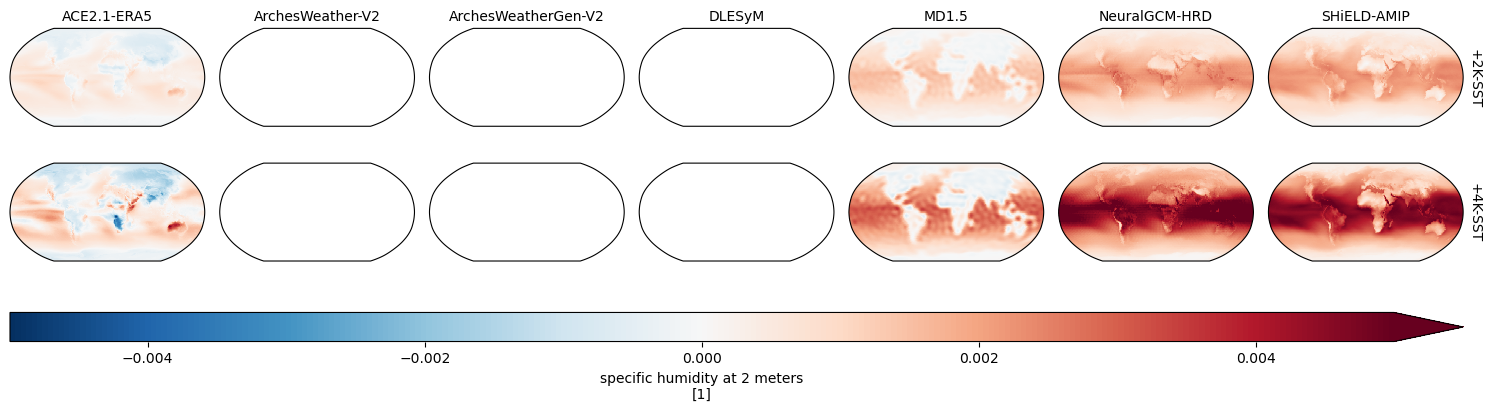

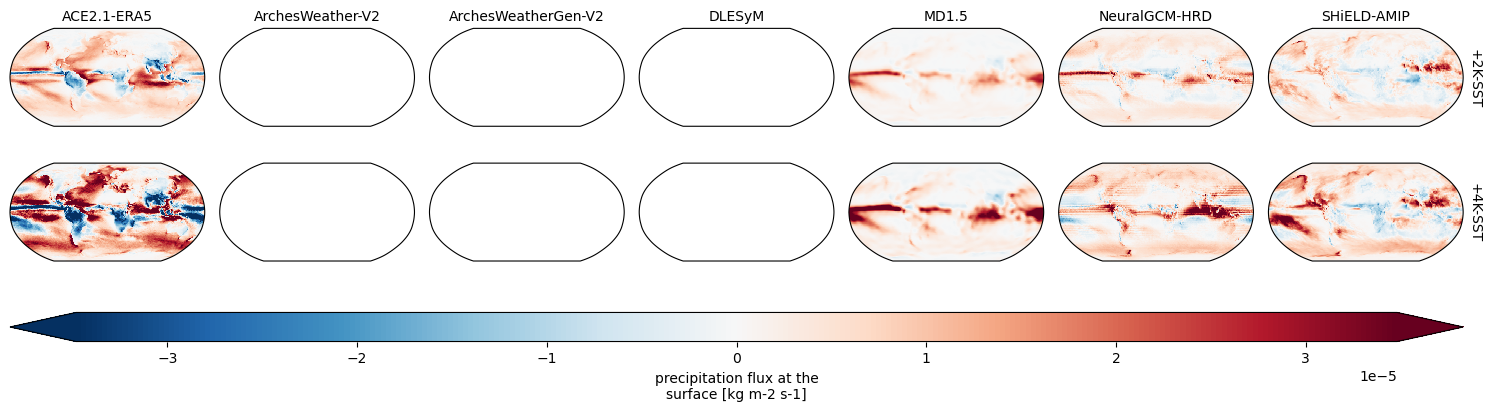

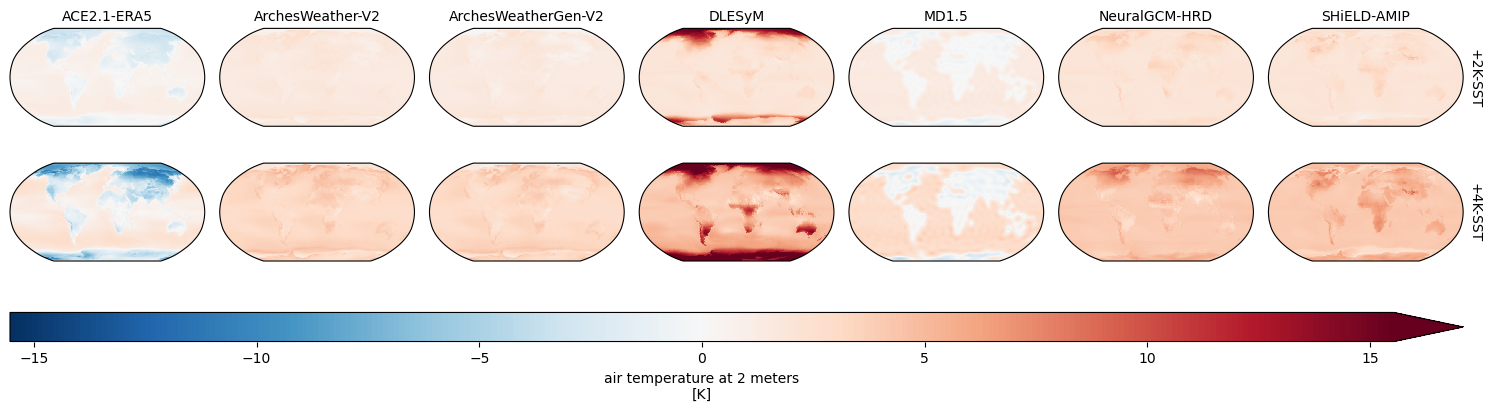

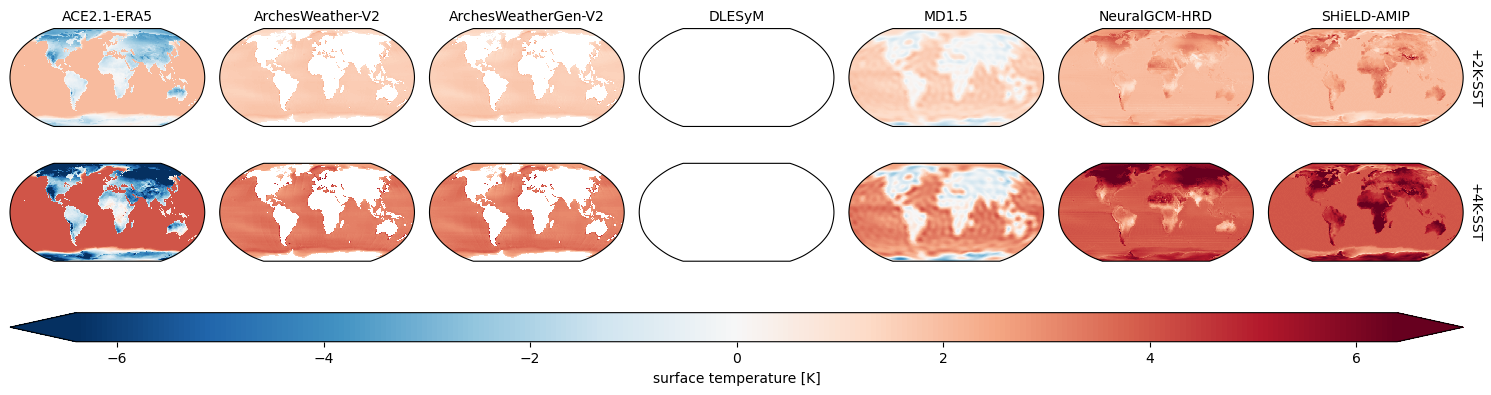

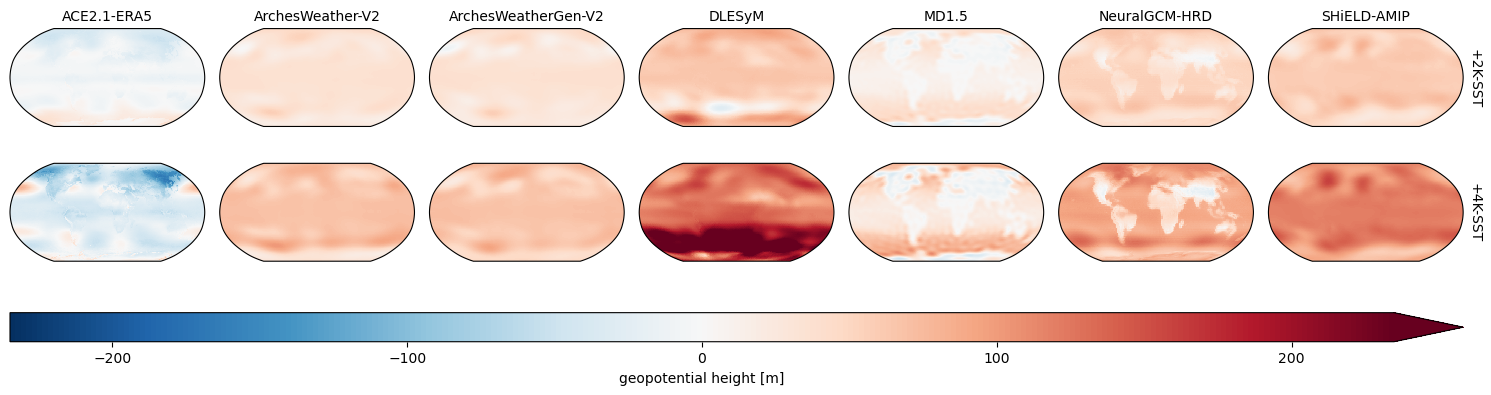

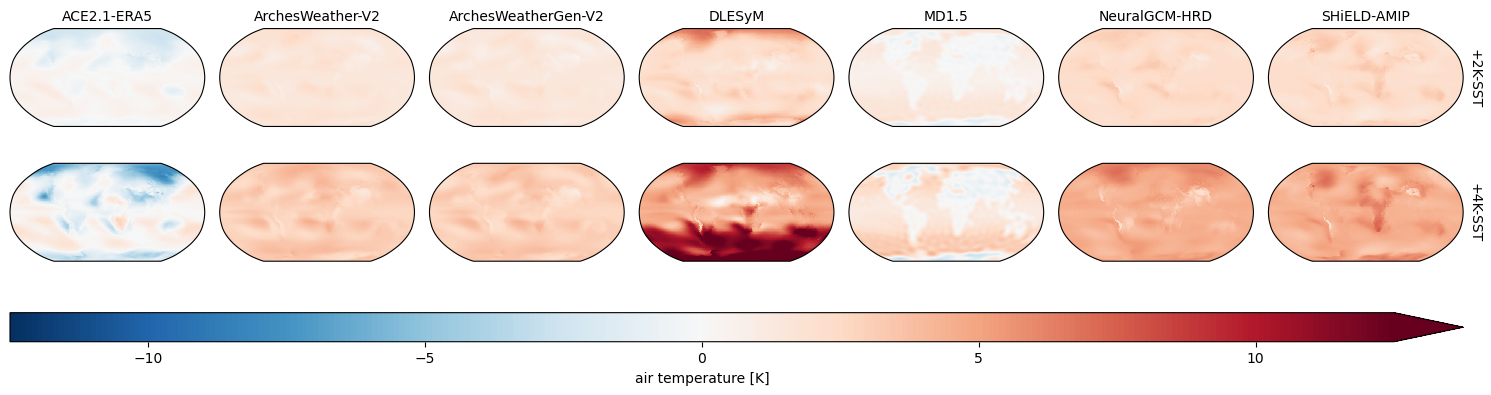

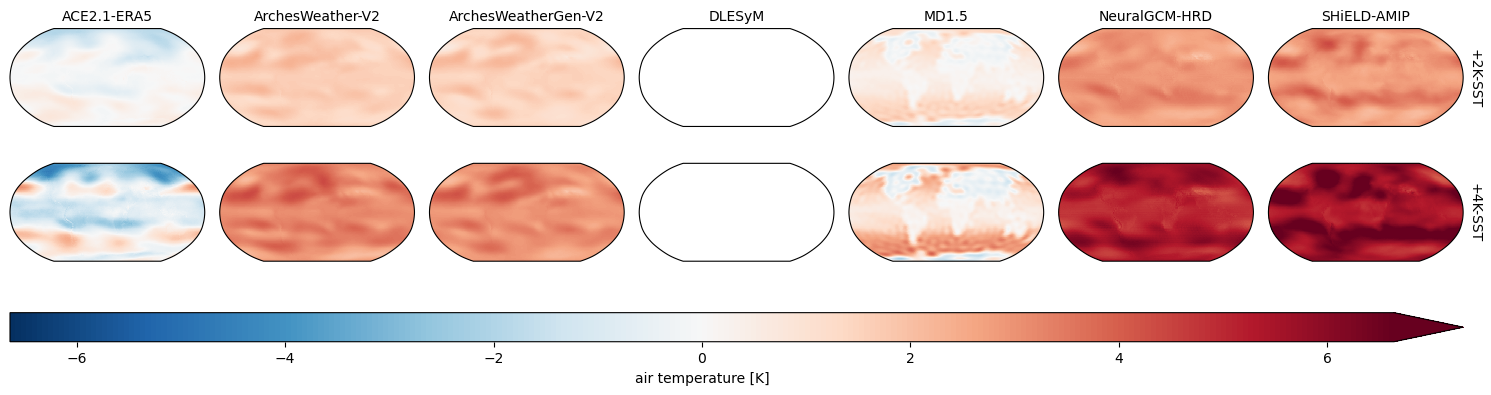

In [54]:
for var in combined_1deg_perturbed_sst_response_time_means.data_vars:
    plottable = combined_1deg_perturbed_sst_response_time_means[var]
    if "plev" in plottable.dims:
        plottable = plottable.isel(plev=0)
    vmax = plottable.quantile(0.99)
    fg = plottable.plot(
        figsize=(15, 4),
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        col='experiment_submission', row='perturbation',
        vmin=-vmax, vmax=vmax, cmap='RdBu_r',
        cbar_kwargs=dict(orientation='horizontal', aspect=50),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'perturbed_sst_response_map_1deg_{var}.png'), bbox_inches='tight')

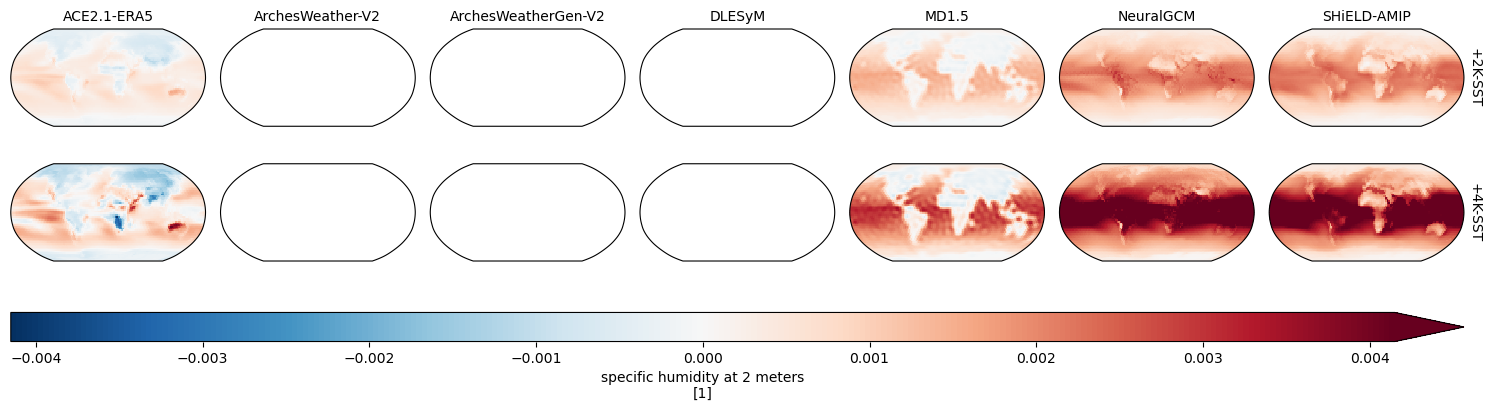

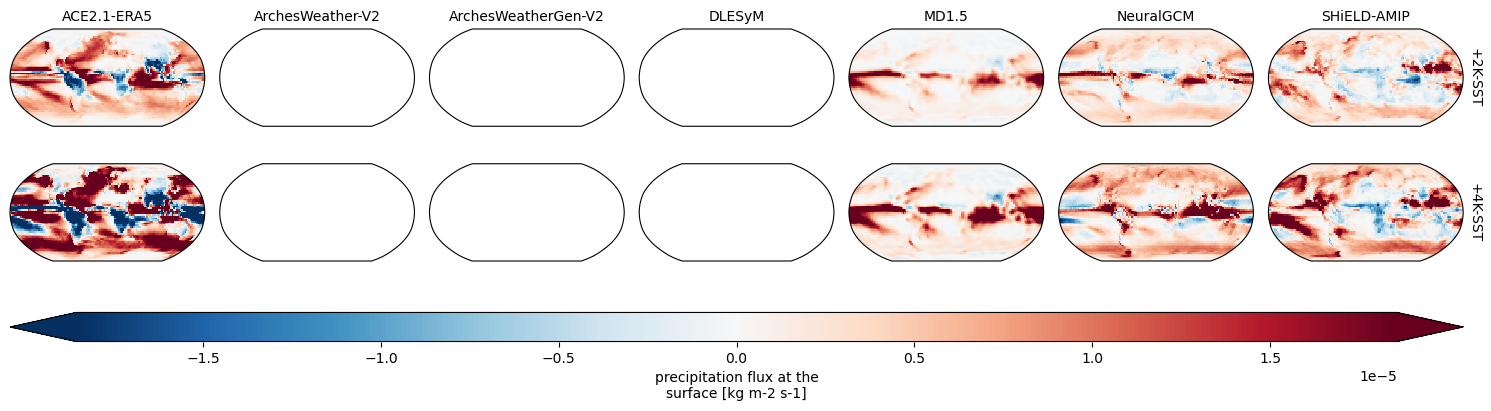

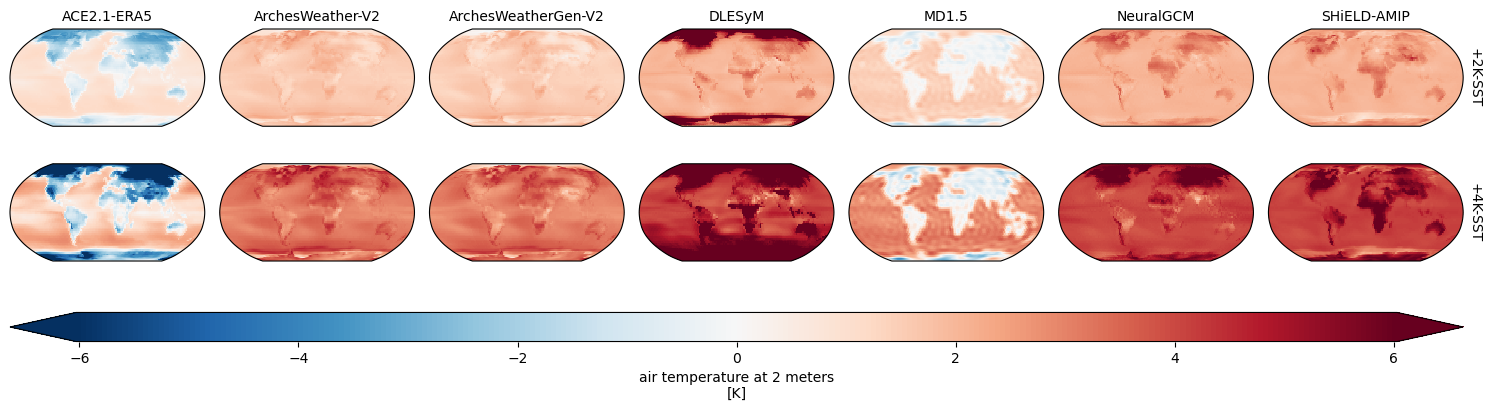

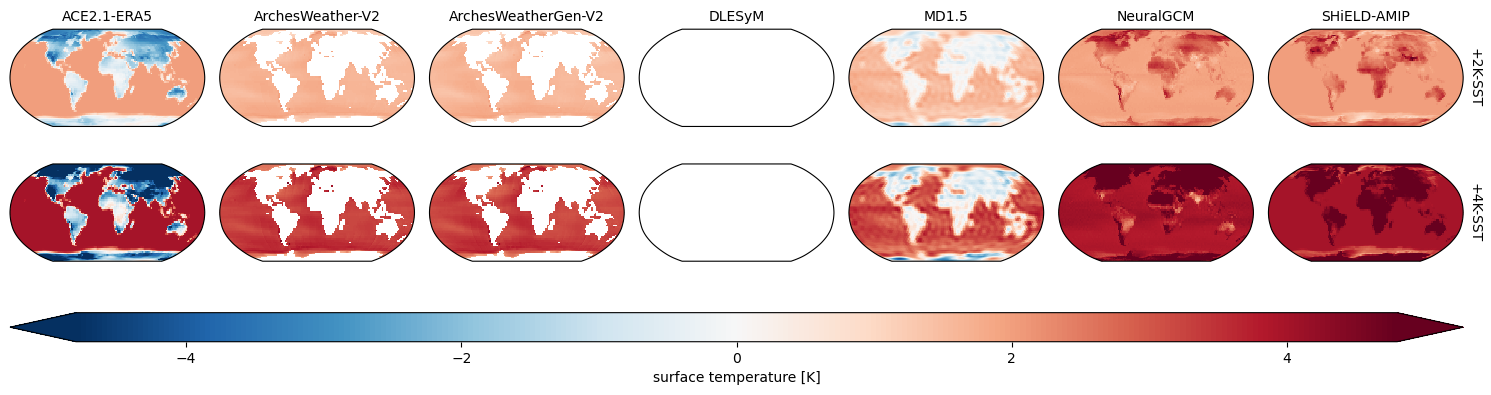

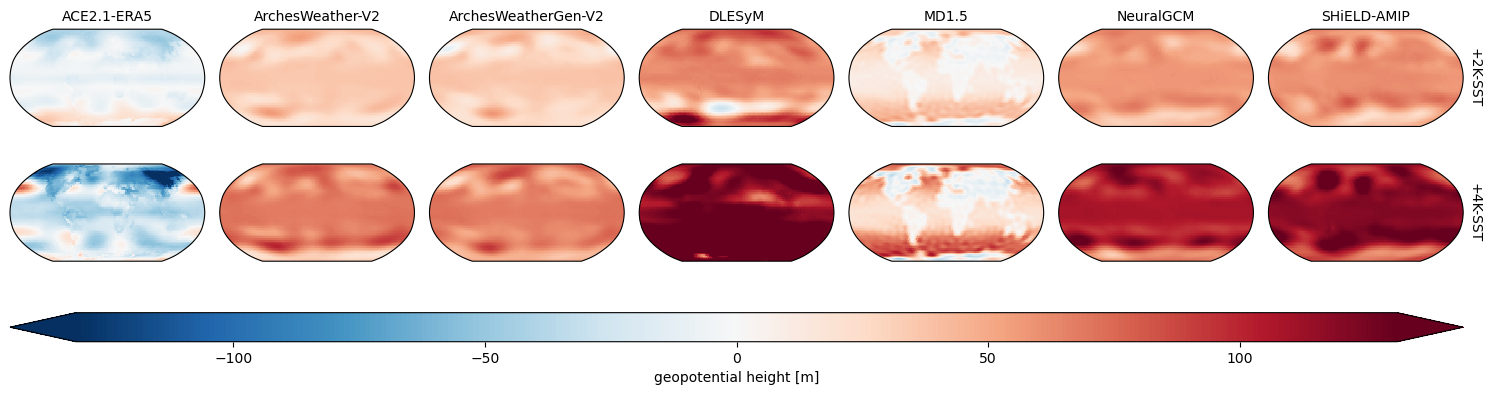

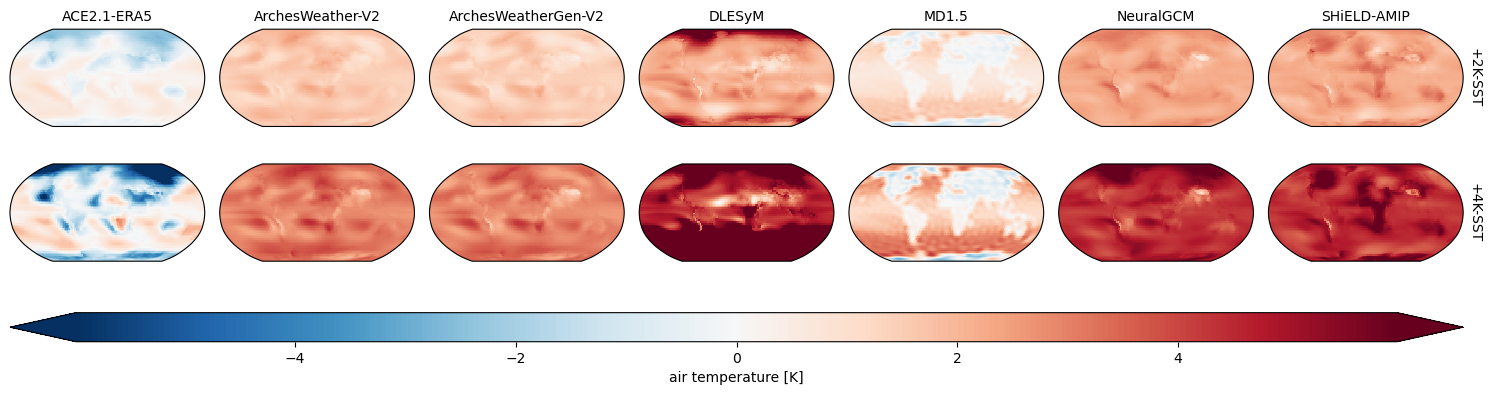

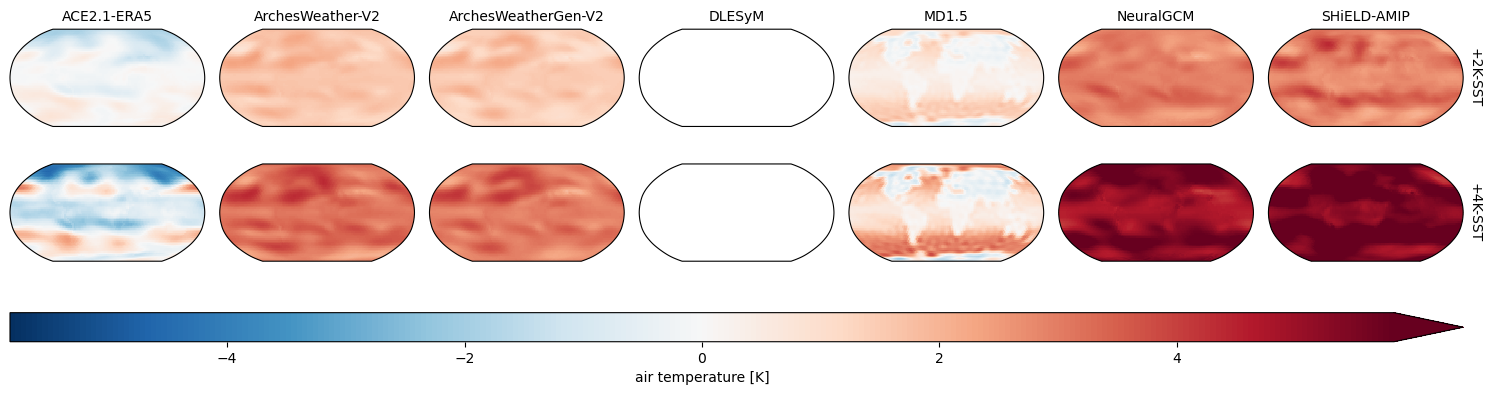

In [55]:
for var in combined_2p8deg_perturbed_sst_response_time_means.data_vars:
    plottable = combined_2p8deg_perturbed_sst_response_time_means[var]
    if "plev" in plottable.dims:
        plottable = plottable.isel(plev=0)
    vmax = plottable.quantile(0.95)
    fg = plottable.plot(
        figsize=(15, 4),
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        col='experiment_submission', row='perturbation',
        vmin=-vmax, vmax=vmax, cmap='RdBu_r',
        cbar_kwargs=dict(orientation='horizontal', aspect=50),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'perturbed_sst_response_map_2p8deg_{var}.png'), bbox_inches='tight')